
=== Original ===
Nodes      : 100
Edges      : 371
Avg degree : 7.42

=== Random ===
Nodes      : 100
Edges      : 111
Avg degree : 2.22

=== Degree ===
Nodes      : 100
Edges      : 111
Avg degree : 2.22

=== PageRank ===
Nodes      : 100
Edges      : 111
Avg degree : 2.22

=== Betweenness ===
Nodes      : 100
Edges      : 111
Avg degree : 2.22

=== k-core ===
Nodes      : 100
Edges      : 370
Avg degree : 7.40

=== Weight ===
Nodes      : 100
Edges      : 111
Avg degree : 2.22

=== Local Top-k ===
Nodes      : 100
Edges      : 130
Avg degree : 2.60

=== Resistance-like ===
Nodes      : 100
Edges      : 111
Avg degree : 2.22

=== Spanner-like ===
Nodes      : 100
Edges      : 327
Avg degree : 6.54

Summary
Original         edges= 371 edge_ratio=1.00
Random           edges= 111 edge_ratio=0.30
Degree           edges= 111 edge_ratio=0.30
PageRank         edges= 111 edge_ratio=0.30
Betweenness      edges= 111 edge_ratio=0.30
k-core           edges= 370 edge_ratio=1.00
Weight           e

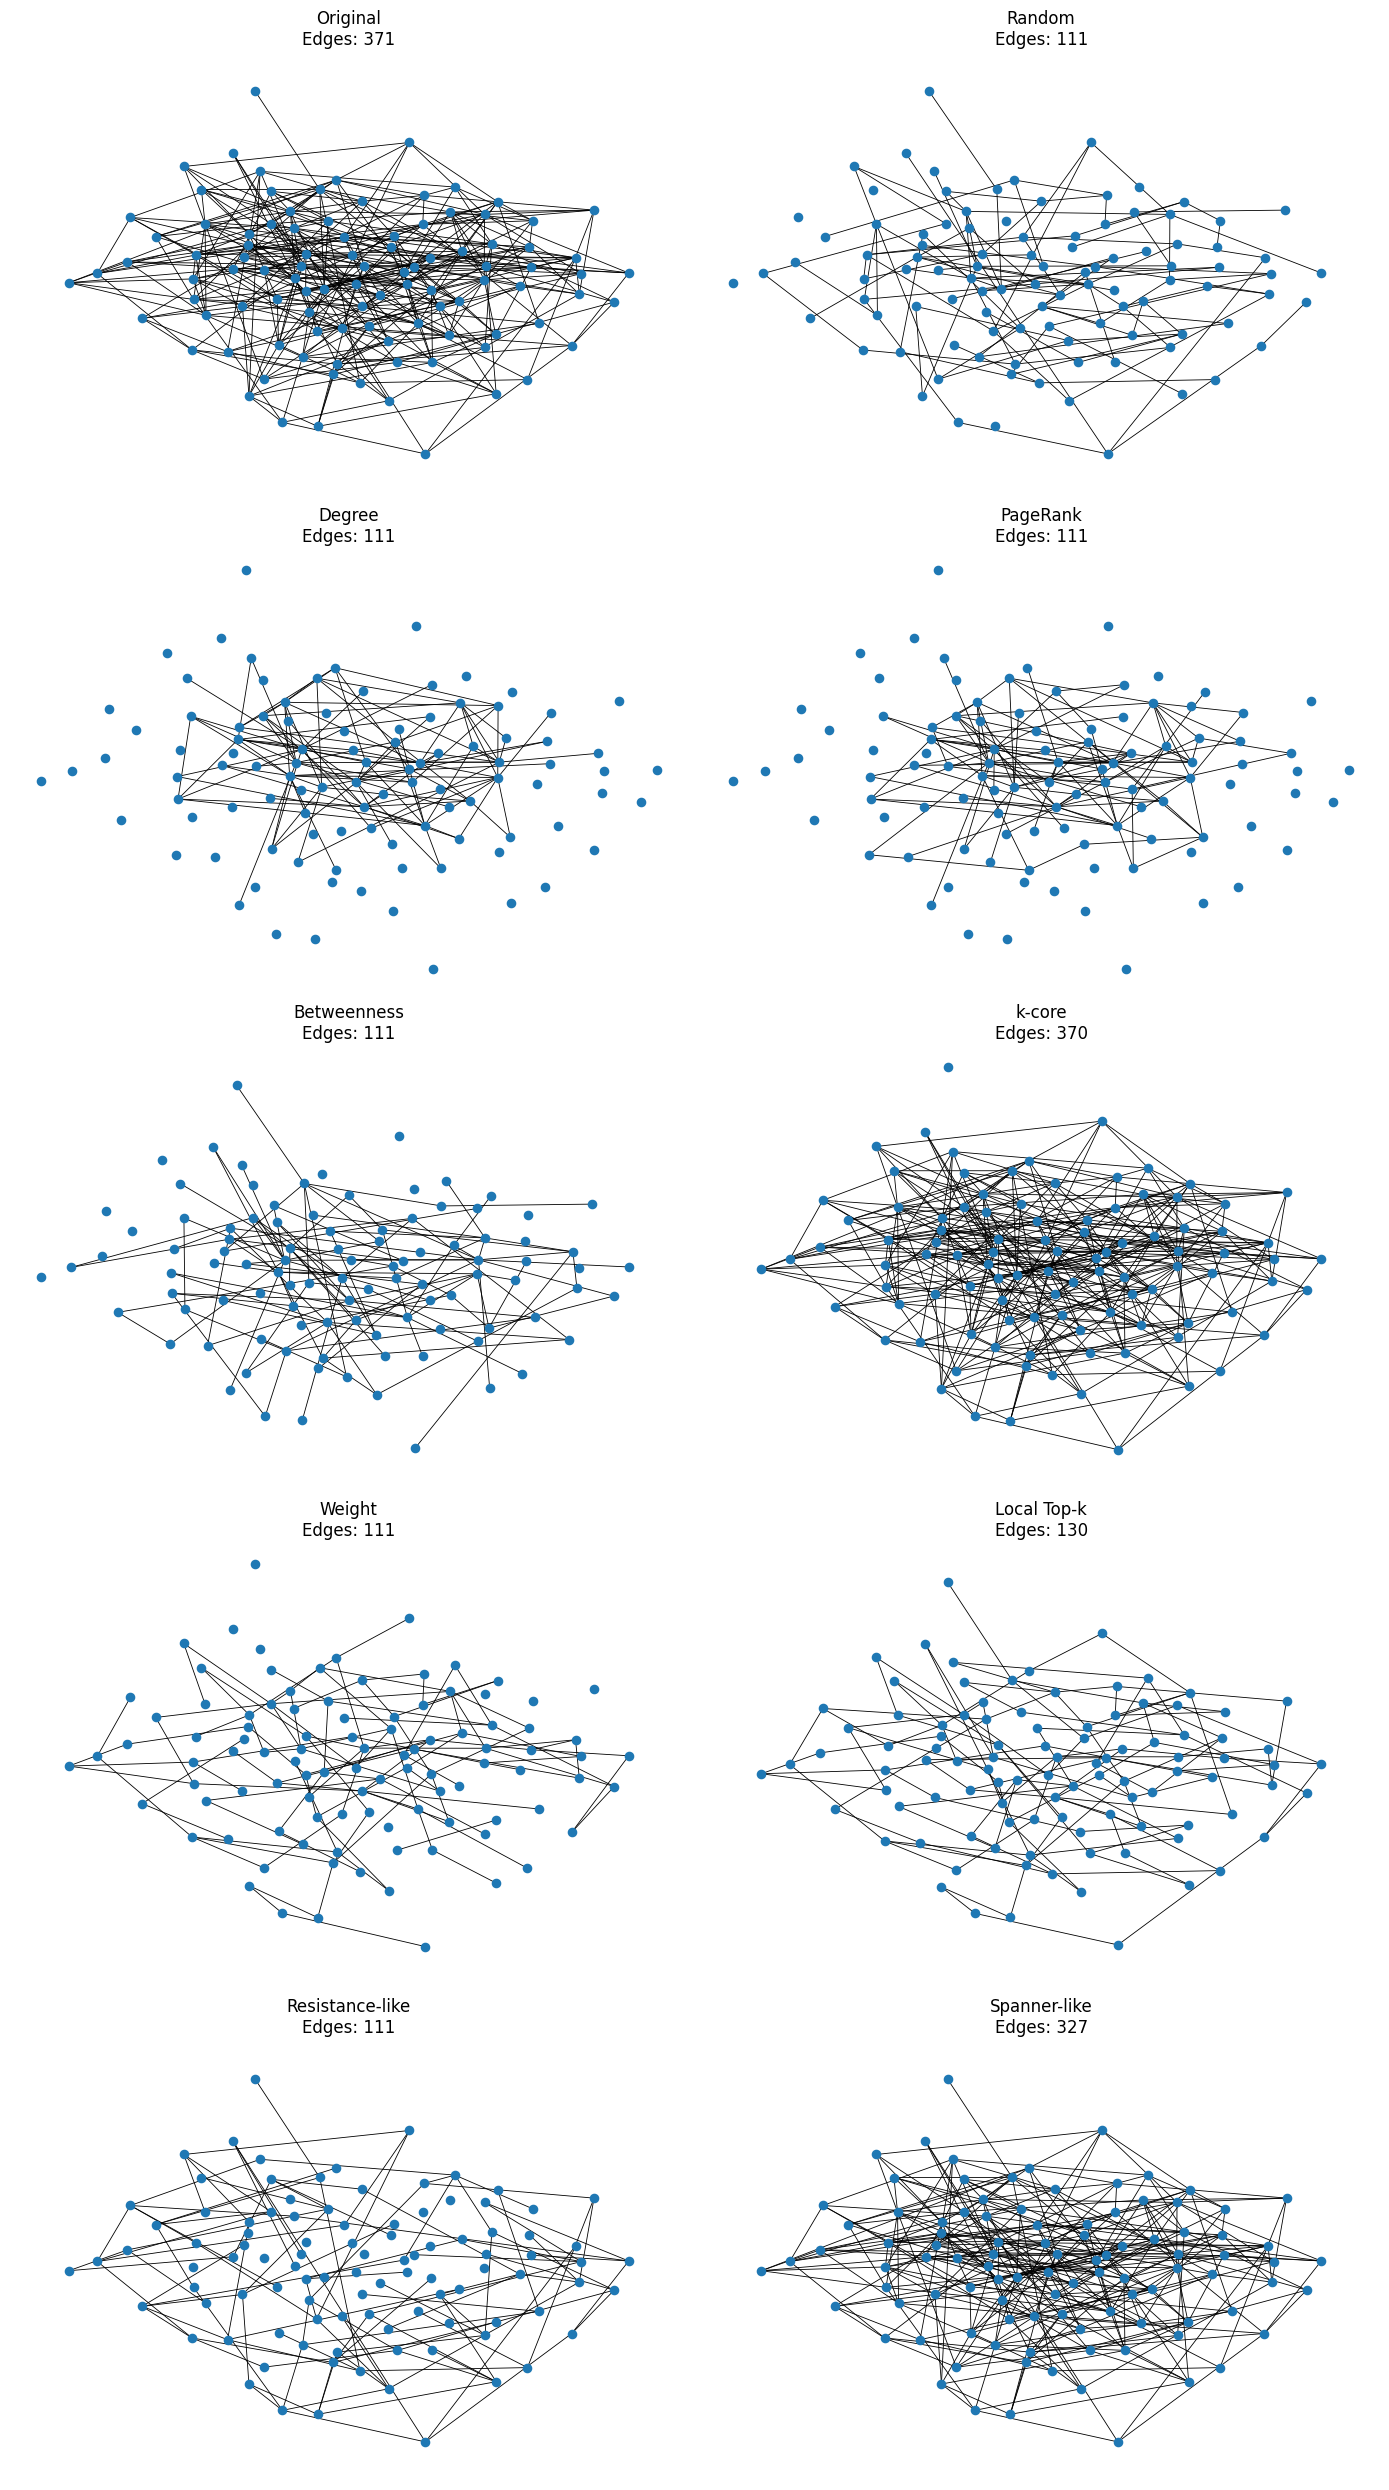

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import random
import numpy as np

# =========================
# パラメータ
# =========================
NUM_NODES = 100
EDGE_PROB = 0.08
SPARSIFY_RATIO = 0.3
SEED = 42

K_CORE = 2
LOCAL_TOP_K = 2
SPANNER_STRETCH = 2

random.seed(SEED)
np.random.seed(SEED)

# =========================
# 元グラフ生成
# =========================
G = nx.erdos_renyi_graph(
    n=NUM_NODES,
    p=EDGE_PROB,
    seed=SEED
)

# 重みを付与
for u, v in G.edges():
    G[u][v]["weight"] = random.random()

# =========================
# 共通関数
# =========================
def make_graph_from_edges(G, selected_edges):
    H = nx.Graph()
    H.add_nodes_from(G.nodes())
    H.add_edges_from(selected_edges)
    return H


def keep_top_edges_by_score(G, edge_scores, ratio):
    edges = list(G.edges())
    num_keep = max(1, int(len(edges) * ratio))

    sorted_edges = sorted(
        edges,
        key=lambda e: edge_scores.get(tuple(sorted(e)), 0),
        reverse=True
    )

    return make_graph_from_edges(G, sorted_edges[:num_keep])


def print_graph_info(name, H):
    avg_degree = sum(dict(H.degree()).values()) / H.number_of_nodes()

    print(f"\n=== {name} ===")
    print(f"Nodes      : {H.number_of_nodes()}")
    print(f"Edges      : {H.number_of_edges()}")
    print(f"Avg degree : {avg_degree:.2f}")


# =========================
# 1. ランダム疎化
# =========================
def random_sparsification(G, ratio):
    edges = list(G.edges())
    num_keep = max(1, int(len(edges) * ratio))
    sampled_edges = random.sample(edges, num_keep)
    return make_graph_from_edges(G, sampled_edges)


# =========================
# 2. Degree-based 疎化
# =========================
def degree_based_sparsification(G, ratio):
    deg = dict(G.degree())

    edge_scores = {}
    for u, v in G.edges():
        edge_scores[tuple(sorted((u, v)))] = deg[u] + deg[v]

    return keep_top_edges_by_score(G, edge_scores, ratio)


# =========================
# 3. PageRank-based 疎化
# =========================
def pagerank_based_sparsification(G, ratio):
    pr = nx.pagerank(G)

    edge_scores = {}
    for u, v in G.edges():
        edge_scores[tuple(sorted((u, v)))] = pr[u] + pr[v]

    return keep_top_edges_by_score(G, edge_scores, ratio)


# =========================
# 4. Edge Betweenness 疎化
# =========================
def edge_betweenness_sparsification(G, ratio):
    eb = nx.edge_betweenness_centrality(G)

    edge_scores = {}
    for e, score in eb.items():
        edge_scores[tuple(sorted(e))] = score

    return keep_top_edges_by_score(G, edge_scores, ratio)


# =========================
# 5. k-core 疎化
# =========================
def k_core_sparsification(G, k):
    core_nodes = nx.k_core(G, k=k).nodes()

    H = G.subgraph(core_nodes).copy()

    # 孤立ノードも残す
    H.add_nodes_from(G.nodes())

    return H


# =========================
# 6. Weight Threshold 疎化
# =========================
def weight_threshold_sparsification(G, ratio):
    edges = list(G.edges(data=True))
    num_keep = max(1, int(len(edges) * ratio))

    sorted_edges = sorted(
        edges,
        key=lambda x: x[2].get("weight", 0),
        reverse=True
    )

    selected_edges = [(u, v) for u, v, _ in sorted_edges[:num_keep]]

    return make_graph_from_edges(G, selected_edges)


# =========================
# 7. Local Top-k 疎化
# =========================
def local_top_k_sparsification(G, k):
    selected_edges = set()

    for node in G.nodes():
        neighbors = list(G.neighbors(node))

        scored_neighbors = []
        for nbr in neighbors:
            score = G[node][nbr].get("weight", 1.0)
            scored_neighbors.append((nbr, score))

        scored_neighbors.sort(key=lambda x: x[1], reverse=True)

        for nbr, _ in scored_neighbors[:k]:
            selected_edges.add(tuple(sorted((node, nbr))))

    return make_graph_from_edges(G, list(selected_edges))


# =========================
# 8. Effective Resistance 近似疎化
# =========================
def effective_resistance_like_sparsification(G, ratio):
    # 厳密な有効抵抗ではなく、
    # 「次数が低いノード間の橋渡し辺」をやや重視する近似版
    deg = dict(G.degree())

    edge_scores = {}
    for u, v in G.edges():
        score = 1 / max(1, deg[u]) + 1 / max(1, deg[v])
        edge_scores[tuple(sorted((u, v)))] = score

    return keep_top_edges_by_score(G, edge_scores, ratio)


# =========================
# 9. Spanner風 疎化
# =========================
def spanner_like_sparsification(G, stretch=2):
    H = nx.Graph()
    H.add_nodes_from(G.nodes())

    edges = list(G.edges())
    random.shuffle(edges)

    for u, v in edges:
        if not nx.has_path(H, u, v):
            H.add_edge(u, v)
        else:
            try:
                dist = nx.shortest_path_length(H, u, v)
                if dist > stretch:
                    H.add_edge(u, v)
            except nx.NetworkXNoPath:
                H.add_edge(u, v)

    return H


# =========================
# 疎化実行
# =========================
graphs = {}

graphs["Original"] = G
graphs["Random"] = random_sparsification(G, SPARSIFY_RATIO)
graphs["Degree"] = degree_based_sparsification(G, SPARSIFY_RATIO)
graphs["PageRank"] = pagerank_based_sparsification(G, SPARSIFY_RATIO)
graphs["Betweenness"] = edge_betweenness_sparsification(G, SPARSIFY_RATIO)
graphs["k-core"] = k_core_sparsification(G, K_CORE)
graphs["Weight"] = weight_threshold_sparsification(G, SPARSIFY_RATIO)
graphs["Local Top-k"] = local_top_k_sparsification(G, LOCAL_TOP_K)
graphs["Resistance-like"] = effective_resistance_like_sparsification(G, SPARSIFY_RATIO)
graphs["Spanner-like"] = spanner_like_sparsification(G, SPANNER_STRETCH)

# =========================
# 結果表示
# =========================
for name, H in graphs.items():
    print_graph_info(name, H)

# =========================
# 比較表
# =========================
print("\n==============================")
print("Summary")
print("==============================")

for name, H in graphs.items():
    edge_ratio = H.number_of_edges() / G.number_of_edges()

    print(
        f"{name:16s} "
        f"edges={H.number_of_edges():4d} "
        f"edge_ratio={edge_ratio:.2f}"
    )

# =========================
# 描画
# =========================
pos = nx.spring_layout(G, seed=SEED)

num_graphs = len(graphs)
cols = 2
rows = int(np.ceil(num_graphs / cols))

fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 5))
axes = axes.flatten()

for ax, (name, H) in zip(axes, graphs.items()):
    nx.draw(
        H,
        pos,
        ax=ax,
        node_size=35,
        width=0.6,
        with_labels=False
    )

    ax.set_title(
        f"{name}\n"
        f"Edges: {H.number_of_edges()}"
    )

for i in range(len(graphs), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()